In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn as sk
import statsmodels
from datetime import datetime

In [30]:
sample = pd.read_csv("sample_submission.csv", parse_dates=True, index_col=0)
sample

,Predicted
Date,
2017-04-13,0
2017-04-14,0
2017-04-17,0
2017-04-18,0
2017-04-19,0
...,...
2021-09-07,0
2021-09-08,0
2021-09-09,0


In [3]:
def parser(s):
    return datetime.strptime(s, "%Y-%m-%d")

In [4]:
data = pd.read_csv("data.csv", parse_dates=[0], date_parser=parser,
                   index_col=0)
data = data.asfreq("B")  # set frequency to business days
data

,Open,High,Low,Close,Volume
Date,,,,,
2010-09-13,15400.0,15519.0,15320.0,15400.0,234851.0
2010-09-14,15500.0,15620.0,15200.0,15200.0,371530.0
2010-09-15,15260.0,15340.0,15020.0,15140.0,389289.0
2010-09-16,15080.0,15260.0,15080.0,15140.0,234815.0
2010-09-17,15240.0,15560.0,15159.0,15460.0,447649.0
...,...,...,...,...,...
2017-04-06,42000.0,42080.0,41600.0,41840.0,193668.0
2017-04-07,41800.0,41820.0,41160.0,41600.0,200420.0
2017-04-10,41940.0,41940.0,41500.0,41940.0,142827.0


Check for missing values:

In [5]:
pd.isnull(data).sum()

Open      90
High      90
Low       90
Close     90
Volume    90
dtype: int64

Since there are only 90 missing values out of 1718 rows, we can just fill them with linear interpolation

In [6]:
data["Close"].interpolate(method="linear", inplace=True)
data["Open"].interpolate(method="linear", inplace=True)
data["Low"].interpolate(method="linear", inplace=True)
data["High"].interpolate(method="linear", inplace=True)
data["Volume"].interpolate(method="linear", inplace=True)

In [7]:
pd.isnull(data).sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
data["Close"]

Date
2010-09-13    15400.0
2010-09-14    15200.0
2010-09-15    15140.0
2010-09-16    15140.0
2010-09-17    15460.0
               ...   
2017-04-06    41840.0
2017-04-07    41600.0
2017-04-10    41940.0
2017-04-11    41600.0
2017-04-12    41900.0
Freq: B, Name: Close, Length: 1718, dtype: float64

In [9]:
pd.isnull(data["Close"]).sum()

0

### Plotting the data 

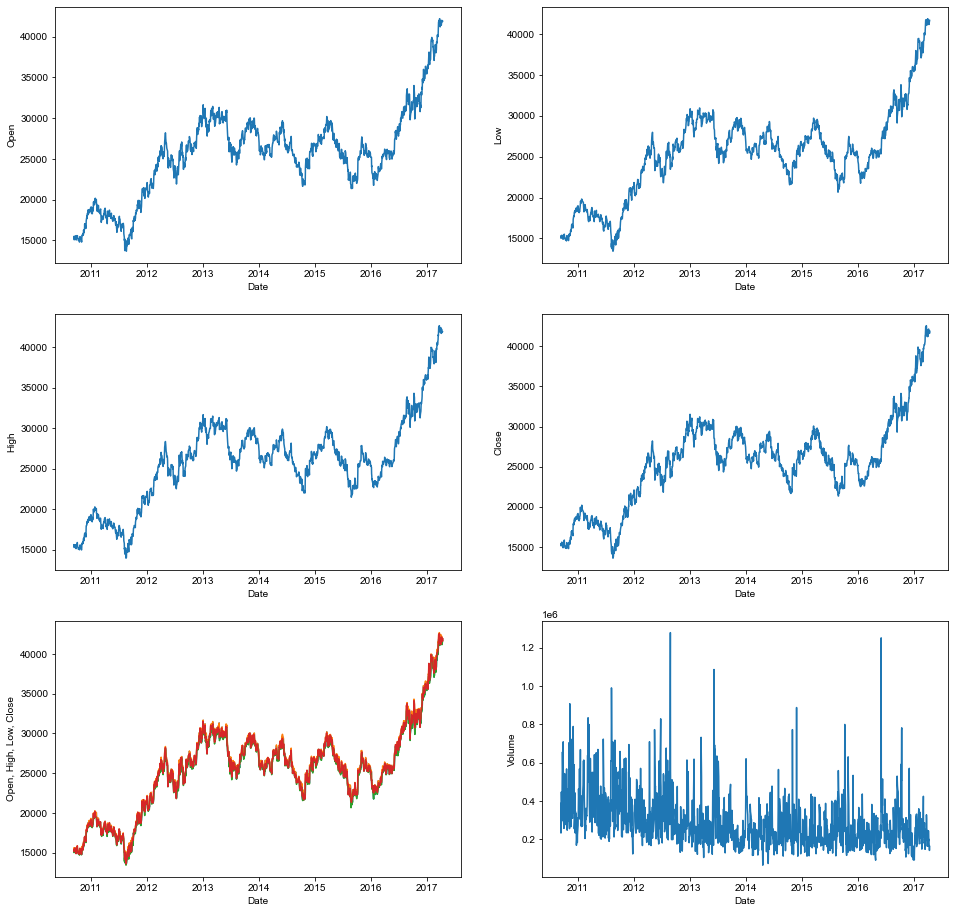

In [10]:
fig, ax = plt.subplots(3, 2, figsize=(16, 16))
sns.set(rc={'figure.figsize':(12, 12)})

sns.lineplot(ax=ax[0, 0], data=data["Open"])
sns.lineplot(ax=ax[1, 0], data=data["High"])
sns.lineplot(ax=ax[0, 1], data=data["Low"])
sns.lineplot(ax=ax[1, 1], data=data["Close"])

sns.lineplot(ax=ax[2, 0], data=data["Open"])
sns.lineplot(ax=ax[2, 0], data=data["High"])
sns.lineplot(ax=ax[2, 0], data=data["Low"])
sns.lineplot(ax=ax[2, 0], data=data["Close"])
ax[2, 0].set_ylabel("Open, High, Low, Close")

sns.lineplot(ax=ax[2, 1], data=data["Volume"]);


The Open, High, and Low trend upwards (overall increasing mean), have (visually) almost constant standard deviation, and (visually) no seasonality. 
- They are not stationary, which means an ordinary ARMA model won't work that well. 
- We will use the ARIMA model

Volume trends slightly downwards (overall slightly decreasing mean), has (visually) fluctuating standard deviation and possible seasonality within each year. 
- It is not stationary. 
- We will incorporate Volume in a more complex model if necessary


Also, by the 5th chart, Open, High, Low, and Close are visually identical. We try a simplest model first, only using close. 

# ARIMA with 1 feature.

### Approach:
1. Determine optimal differencing parameter d.
2. Plot PACF to determine which p's to test out.
3. Plot ACF to determine which q's to test out.
4. Predict and evaluate the error.

### Determining optimal differencing parameter d

In [11]:
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return pd.Series(diff, index=data.index[interval:]) 

def inverse_difference(X, Z):
    result = X.copy()
    for i in range(1, len(X)):
        result.iloc[i] = result.iloc[i - 1] + Z.iloc[i - 1]
    return result

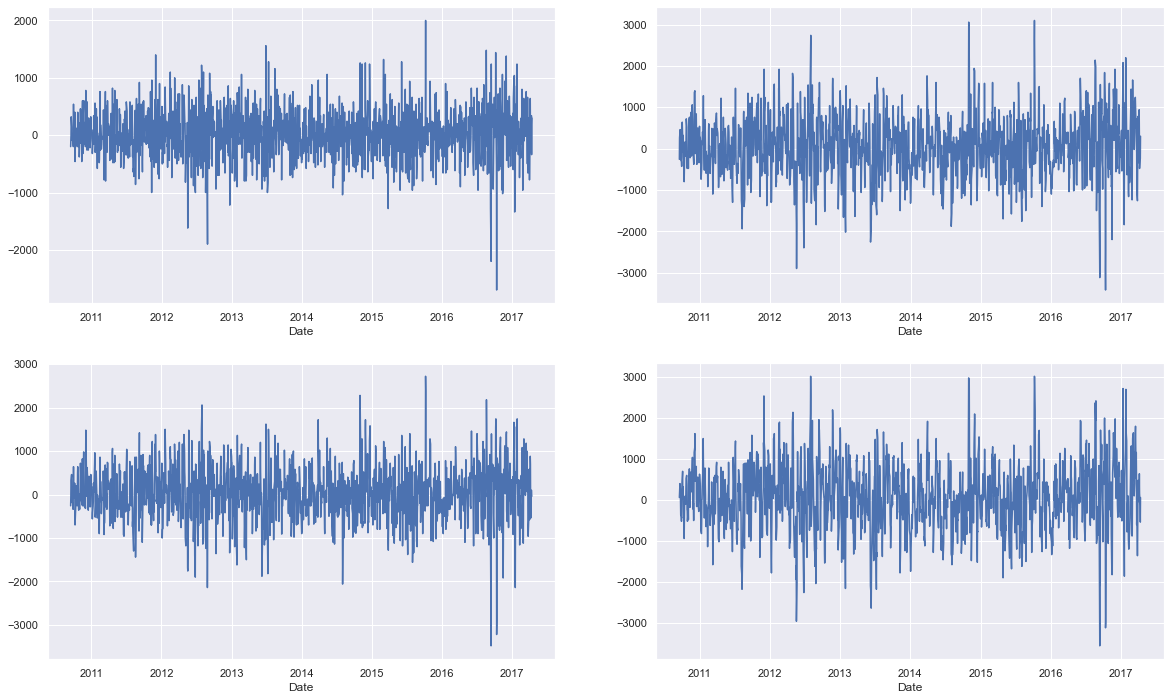

In [12]:
d1 = difference(data["Close"], 1)
d2 = difference(data["Close"], 2)
d3 = difference(data["Close"], 3)
d4 = difference(data["Close"], 4)

fig, ax = plt.subplots(2, 2, figsize=(20, 12))
sns.lineplot(ax=ax[0, 0], data=d1);
sns.lineplot(ax=ax[1, 0], data=d2);
sns.lineplot(ax=ax[0, 1], data=d3);
sns.lineplot(ax=ax[1, 1], data=d4);

Visually, d=1 is stationary. In fact, increase d *seems* to introduce seasonality into the data. We'll verify that differencing the data with d=1 gives us a stationary result using the Augmented Dickey-Fuller test. 

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=["Test Statistic",
               "p-value",
               "#Lags Used",
               "Number of Observations Used"],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [14]:
adf_test(d1)

Results of Dickey-Fuller Test:
Test Statistic                  -23.442621
p-value                           0.000000
#Lags Used                        3.000000
Number of Observations Used    1713.000000
Critical Value (1%)              -3.434173
Critical Value (5%)              -2.863229
Critical Value (10%)             -2.567669
dtype: float64


In [15]:
adf_test(d2)

Results of Dickey-Fuller Test:
Test Statistic                -7.967726e+00
p-value                        2.835242e-12
#Lags Used                     2.500000e+01
Number of Observations Used    1.690000e+03
Critical Value (1%)           -3.434225e+00
Critical Value (5%)           -2.863252e+00
Critical Value (10%)          -2.567681e+00
dtype: float64


In [16]:
adf_test(d3)

Results of Dickey-Fuller Test:
Test Statistic                -7.652637e+00
p-value                        1.772593e-11
#Lags Used                     2.500000e+01
Number of Observations Used    1.689000e+03
Critical Value (1%)           -3.434228e+00
Critical Value (5%)           -2.863253e+00
Critical Value (10%)          -2.567682e+00
dtype: float64


In [17]:
adf_test(d4)

Results of Dickey-Fuller Test:
Test Statistic                -7.528861e+00
p-value                        3.623261e-11
#Lags Used                     2.500000e+01
Number of Observations Used    1.688000e+03
Critical Value (1%)           -3.434230e+00
Critical Value (5%)           -2.863254e+00
Critical Value (10%)          -2.567682e+00
dtype: float64


The p-values of the Dickey-Fuller test using d=1, 2, 3, 4 are all less than significance levels of both 0.01 and 0.05. They are all stationary. 

Hence, d=1, 2, 3, 4 will all work.

### Plotting PACF to determine p

In [18]:
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
register_matplotlib_converters()

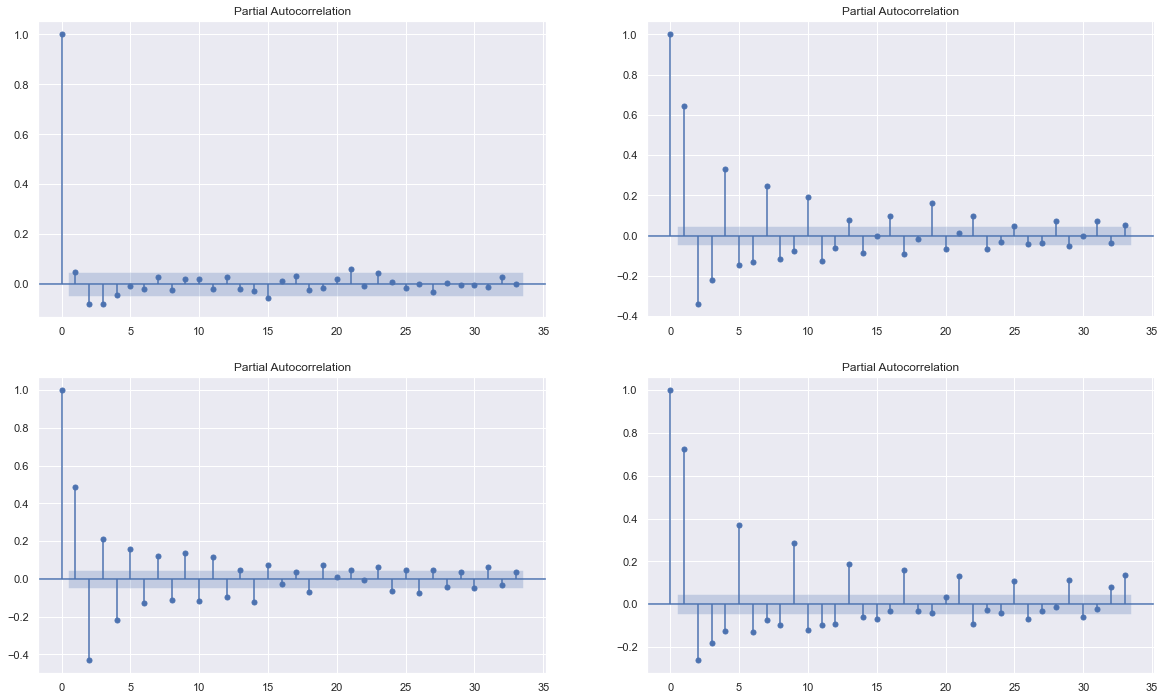

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
plot_pacf(ax=ax[0, 0], x=d1)
plot_pacf(ax=ax[1, 0], x=d2)
plot_pacf(ax=ax[0, 1], x=d3)
plot_pacf(ax=ax[1, 1], x=d4);

When d=1, the 2nd, 3rd, 23rd, and 26th lags seem correlated. We can test out p=3.

When d>1, it seems like correlation is strong even after p>35. We'll explore this if the simplest solution gives unsatisfactory results.

### Plotting ACF to determine q

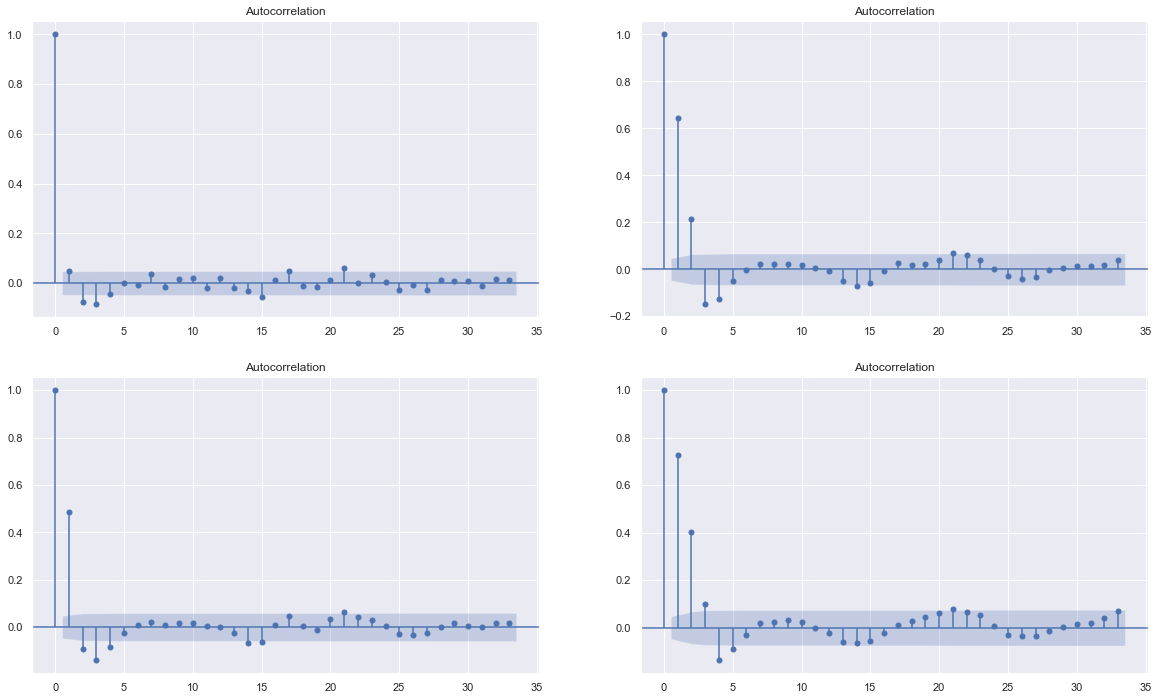

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
plot_acf(ax=ax[0, 0], x=d1)
plot_acf(ax=ax[1, 0], x=d2)
plot_acf(ax=ax[0, 1], x=d3)
plot_acf(ax=ax[1, 1], x=d4);

When d=1, the 2nd, 3rd, and 26th lags seem correlated. We can test out q=3 and q=26

When d>1, the correlation roughly stops at the 5th lag. This is actually managable, but due to the strong correlation for p>35 that was shown above, we'll also only explore this if the simplest solution gives unsatisfactory results.

### Modelling

In [21]:
from statsmodels.tsa.arima.model import ARIMA

In [22]:
arima_model = ARIMA(data["Close"], order=(3, 1, 3))
arima_model_fit = arima_model.fit()
print(arima_model_fit.summary());

/Users/cyanaspect/opt/anaconda3/envs/ml/lib/python3.7/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/cyanaspect/opt/anaconda3/envs/ml/lib/python3.7/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1718
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -12778.882
Date:                Tue, 12 Oct 2021   AIC                          25571.764
Time:                        21:55:51   BIC                          25609.902
Sample:                    09-13-2010   HQIC                         25585.876
                         - 04-12-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0515      0.635      0.081      0.935      -1.192       1.295
ar.L2          0.3519      0.454      0.775      0.438      -0.538       1.242
ar.L3         -0.3340      0.227     -1.472      0.1

<AxesSubplot:xlabel='Date', ylabel='predicted_mean'>

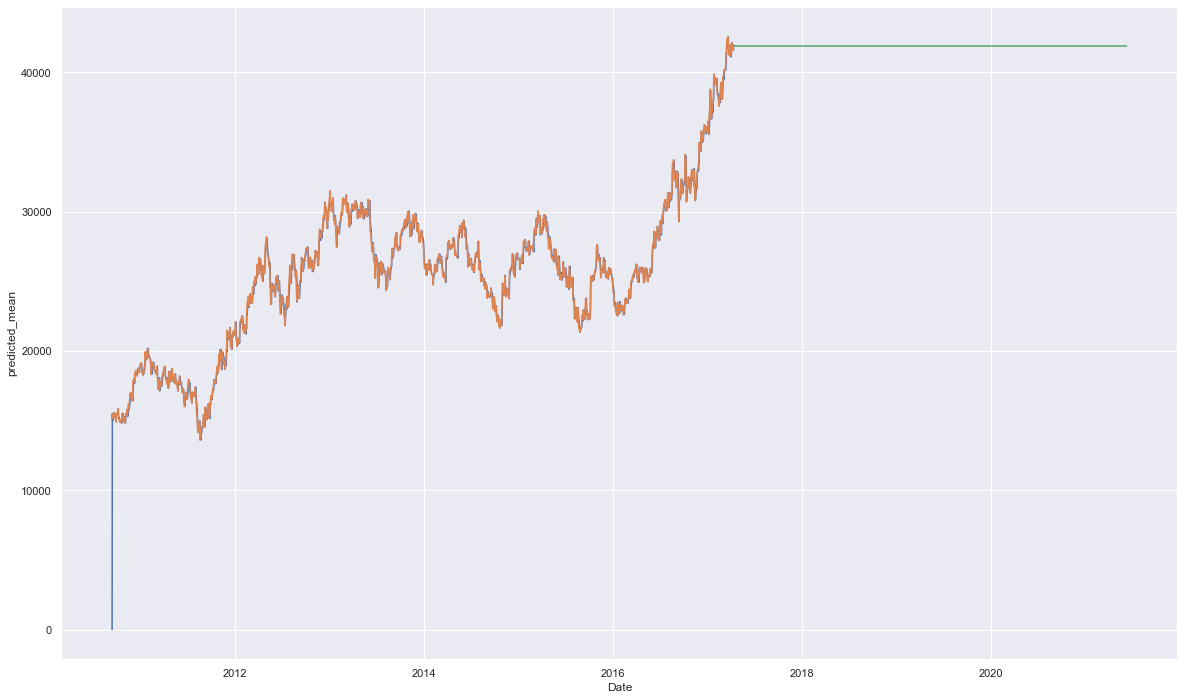

In [23]:
fig, ax = plt.subplots(figsize=(20, 12))
sns.lineplot(ax=ax, data=arima_model_fit.predict());
sns.lineplot(ax=ax, data=data["Close"]);
sns.lineplot(ax=ax, data=arima_model_fit.forecast(1086))


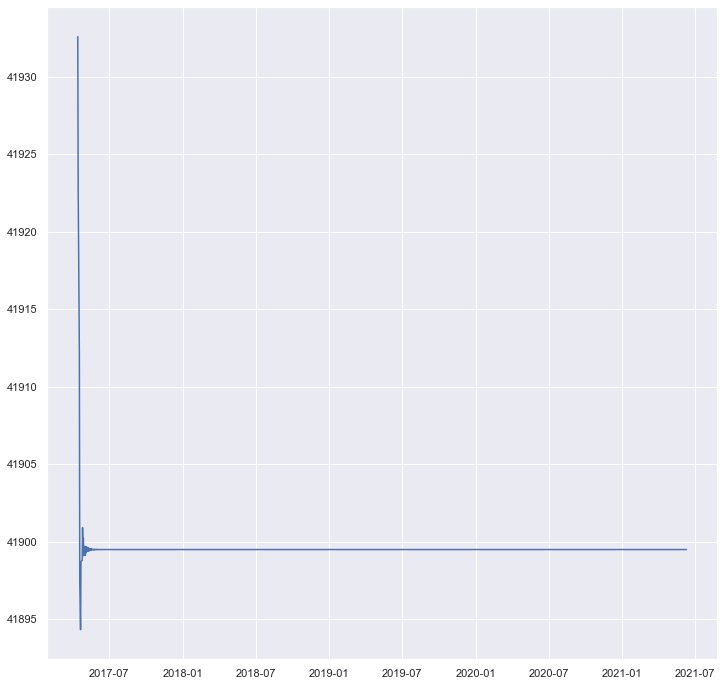

In [24]:
plt.plot(arima_model_fit.forecast(1086))

A flat line. This isn't very promising.

# Auto ARIMA

With ARIMA returning unsatisfactory results, lets try auto ARIMA, which automatically selects the best order for our model. 

In [25]:
import sys
!{sys.executable} -m pip install pmdarima

import pmdarima as pm

In [26]:
model = pm.auto_arima(data["Close"], start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=5, max_q=5, # maximum p and q
                      m=1,              # frequency of series
                      d=1,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=25584.001, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=25586.502, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=25584.906, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=25584.295, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=25586.863, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=25566.433, Time=0.63 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=25576.090, Time=0.11 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=25567.757, Time=0.36 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=25566.733, Time=0.91 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=25568.060, Time=0.53 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=25567.899, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=25569.943, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=25567.897, Time=0.40 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 3.938 seconds


In [35]:
predictions = model.predict(1086)

In [36]:
predictions

array([41952.53061202, 41958.94519832, 41964.23700495, ...,
       58852.69724125, 58868.32912682, 58883.96101238])

In [37]:
sample

,Predicted
Date,
2017-04-13,0
2017-04-14,0
2017-04-17,0
2017-04-18,0
2017-04-19,0
...,...
2021-09-07,0
2021-09-08,0
2021-09-09,0


In [38]:
for i in range(len(sample)):
    sample.iloc[i] = predictions[i]

In [44]:
sample
sample.to_csv("fintech_submission.csv")

,Predicted
Date,
2017-04-13,41952.530612
2017-04-14,41958.945198
2017-04-17,41964.237005
2017-04-18,41974.197425
2017-04-19,41987.337529
...,...
2021-09-07,58821.433470
2021-09-08,58837.065356
2021-09-09,58852.697241


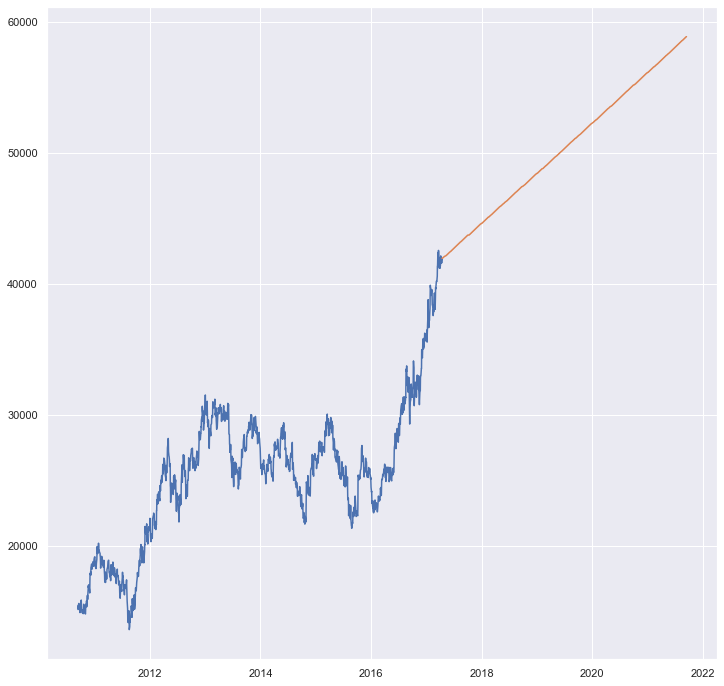

In [28]:
plt.plot(data["Close"])
plt.plot(sample);

Another straight line prediction, but this time it trends upwards. I believe this is the best model we have right now.

We can clearly do better. 

In [153]:
# save our predictions to a csv (only perform once!!)
sample.to_csv("lul.csv")